In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded! ✅")



All libraries loaded! ✅


In [2]:
# Load all 4 datasets
df_states = pd.read_csv('state_accidents_2019_2023.csv')
df_cities = pd.read_csv('cities_accidents_2023.csv')
df_causes = pd.read_csv('causes_violations_2023.csv')
df_users = pd.read_csv('road_users_fatalities_2023.csv')

print("Dataset 1 - States:", df_states.shape)
print("Dataset 2 - Cities:", df_cities.shape)
print("Dataset 3 - Causes:", df_causes.shape)
print("Dataset 4 - Road Users:", df_users.shape)
print("\nAll datasets loaded! ✅")

Dataset 1 - States: (40, 14)
Dataset 2 - Cities: (51, 14)
Dataset 3 - Causes: (13, 10)
Dataset 4 - Road Users: (19, 4)

All datasets loaded! ✅


In [3]:
# Quick look at all 4
print("="*50)
print("STATES DATASET:")
print("="*50)
print(df_states.head(3))

print("\n" + "="*50)
print("CITIES DATASET:")
print("="*50)
print(df_cities.head(3))

print("\n" + "="*50)
print("CAUSES DATASET:")
print("="*50)
print(df_causes)

print("\n" + "="*50)
print("ROAD USERS DATASET:")
print("="*50)
print(df_users)

STATES DATASET:
  Sl No              State 2019 Accidents 2020 Accidents 2021 Accidents  \
0     1     Andhra Pradesh          21992          19509          21556   
1     2  Arunachal Pradesh            237            134            283   
2     3              Assam           8350           6595           7411   

  2022 Accidents 2023 Accidents Change from 2022 to 2023  \
0          21249          19949                    -1300   
1            227            287                       60   
2           7023           7421                      398   

   % change from 2022 to 2023 2019 Ranking  2020 Ranking  2021 Ranking  \
0                        -6.1            8           7.0           7.0   
1                        26.4           30          32.0          28.0   
2                         5.7           16          16.0          16.0   

   2022 Ranking  2023 Ranking  
0           9.0           9.0  
1          31.0          29.0  
2          16.0          16.0  

CITIES DATASET:


In [4]:
# Clean States dataset
# Remove ranking columns - we don't need them
df_states_clean = df_states[['State', '2019 Accidents', '2020 Accidents', 
                              '2021 Accidents', '2022 Accidents', '2023 Accidents',
                              '% change from 2022 to 2023']].copy()

# Remove total/summary rows
df_states_clean = df_states_clean[~df_states_clean['State'].str.contains('Total|UT|All', na=False)]

print("States clean shape:", df_states_clean.shape)
print(df_states_clean.head())

States clean shape: (39, 7)
               State 2019 Accidents 2020 Accidents 2021 Accidents  \
0     Andhra Pradesh          21992          19509          21556   
1  Arunachal Pradesh            237            134            283   
2              Assam           8350           6595           7411   
3              Bihar          10007           8639           9553   
4       Chhattisgarh          13899          11656          12375   

  2022 Accidents 2023 Accidents  % change from 2022 to 2023  
0          21249          19949                        -6.1  
1            227            287                        26.4  
2           7023           7421                         5.7  
3          10801          11014                         2.0  
4          13279          13468                         1.4  


In [5]:
# Convert accident columns to numeric
accident_cols = ['2019 Accidents', '2020 Accidents', '2021 Accidents', 
                 '2022 Accidents', '2023 Accidents']

for col in accident_cols:
    df_states_clean[col] = pd.to_numeric(df_states_clean[col], errors='coerce')

print("Data types:")
print(df_states_clean.dtypes)
print("\nAny missing values?")
print(df_states_clean.isnull().sum())

Data types:
State                             str
2019 Accidents                float64
2020 Accidents                float64
2021 Accidents                float64
2022 Accidents                float64
2023 Accidents                float64
% change from 2022 to 2023    float64
dtype: object

Any missing values?
State                         2
2019 Accidents                3
2020 Accidents                4
2021 Accidents                3
2022 Accidents                2
2023 Accidents                3
% change from 2022 to 2023    3
dtype: int64


In [6]:
# Show rows with missing values
print(df_states_clean[df_states_clean.isnull().any(axis=1)])


          State  2019 Accidents  2020 Accidents  2021 Accidents  \
31  Daman & Diu            69.0             NaN             NaN   
34       Ladakh             NaN             NaN           236.0   
38          NaN             NaN             NaN             NaN   
39          NaN             NaN             NaN             NaN   

    2022 Accidents  2023 Accidents  % change from 2022 to 2023  
31             0.0             NaN                         NaN  
34           374.0           289.0                       -22.7  
38             NaN             NaN                         NaN  
39             NaN             NaN                         NaN  


In [7]:
# Remove completely empty rows
df_states_clean = df_states_clean.dropna(subset=['State'])

# Fill missing accident values with 0
df_states_clean[accident_cols] = df_states_clean[accident_cols].fillna(0)

print("After cleaning:")
print("Shape:", df_states_clean.shape)
print("\nMissing values:")
print(df_states_clean.isnull().sum())

After cleaning:
Shape: (37, 7)

Missing values:
State                         0
2019 Accidents                0
2020 Accidents                0
2021 Accidents                0
2022 Accidents                0
2023 Accidents                0
% change from 2022 to 2023    1
dtype: int64


In [8]:
# Fill missing % change with 0
df_states_clean['% change from 2022 to 2023'] = df_states_clean['% change from 2022 to 2023'].fillna(0)

print("✅ States dataset fully clean!")
print("Final shape:", df_states_clean.shape)
print("\nTop 5 states by 2023 accidents:")
print(df_states_clean.nlargest(5, '2023 Accidents')[['State', '2023 Accidents']])

✅ States dataset fully clean!
Final shape: (37, 7)

Top 5 states by 2023 accidents:
             State  2023 Accidents
22      Tamil Nadu         67213.0
12  Madhya Pradesh         55327.0
11          Kerala         48091.0
26   Uttar Pradesh         44534.0
10       Karnataka         43440.0


In [9]:
# Clean Causes dataset - remove % share rows
df_causes_clean = df_causes[~df_causes['Category'].str.contains('share|All India', na=False)].copy()

# Keep only relevant columns
df_causes_clean = df_causes_clean[['Category', '2023-Accidents', '2023-Killed', '2023-injured']].copy()

# Convert to numeric - remove commas first
for col in ['2023-Accidents', '2023-Killed', '2023-injured']:
    df_causes_clean[col] = df_causes_clean[col].astype(str).str.replace(',', '').str.strip()
    df_causes_clean[col] = pd.to_numeric(df_causes_clean[col], errors='coerce')

print("Causes clean:")
print(df_causes_clean)
print("\nMissing values:", df_causes_clean.isnull().sum().sum())

Causes clean:
                                         Category  2023-Accidents  \
0                                   Over-speeding          328727   
2   Drunken driving/consumption of alcohol & drug            9143   
4         Driving on wrong side/Lane indiscipline           25242   
6                               Jumping red light            2440   
8                             Use of mobile phone            7122   
10                                         Others          107909   

    2023-Killed  2023-injured  
0        117682        320416  
2          3674          8421  
4          9432         24435  
6           818          2157  
8          2884          6445  
10        38400        100951  

Missing values: 0


In [10]:
# Clean Cities dataset - remove commas from numbers
city_num_cols = ['2022 Accidents', '2023 Accidents', '2022 Killed', 
                 '2023 Killed', '2022 Injured', '2023 Injured']

for col in city_num_cols:
    df_cities[col] = df_cities[col].astype(str).str.replace(',', '').str.strip()
    df_cities[col] = pd.to_numeric(df_cities[col], errors='coerce')

# Clean Road Users dataset - remove share rows
df_users_clean = df_users[~df_users['Road-user category'].str.contains('share|Total', na=False)].copy()

# Convert to numeric
df_users_clean['Persons killed 2023'] = df_users_clean['Persons killed 2023'].astype(str).str.replace(',', '').str.strip()
df_users_clean['Persons killed 2023'] = pd.to_numeric(df_users_clean['Persons killed 2023'], errors='coerce')

print("Cities clean shape:", df_cities.shape)
print("Missing in cities:", df_cities[city_num_cols].isnull().sum().sum())
print("\nRoad Users clean:")
print(df_users_clean[['Road-user category', 'Persons killed 2023']])

Cities clean shape: (51, 14)
Missing in cities: 0

Road Users clean:
                                   Road-user category  Persons killed 2023
0                                          Pedestrian                35221
2                                            Bicycles                 4560
4                                        Two-wheelers                77539
6                                      Auto-Rickshaws                 6308
8                            Cars, Taxis, Vans & LMVs                21496
10                                     Trucks/Lorries                10066
12                                              Buses                 3956
14   Other Non- Motor Vehicles (including e-rickshaw)                 2006
16  Others (other motor vehicles, animals drawn ve...                11738


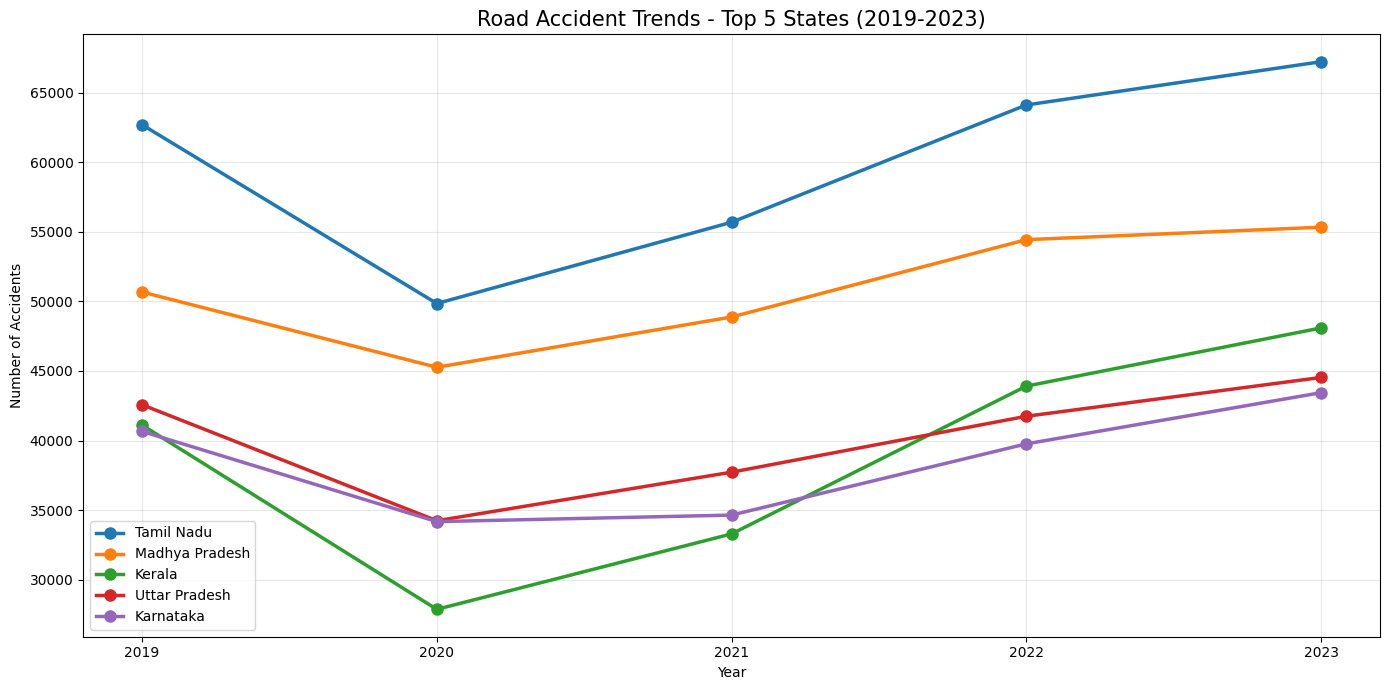

In [11]:
plt.figure(figsize=(14,7))

# Get top 5 states by 2023 accidents
top5_states = df_states_clean.nlargest(5, '2023 Accidents')['State'].tolist()
years = ['2019 Accidents', '2020 Accidents', '2021 Accidents', 
         '2022 Accidents', '2023 Accidents']
year_labels = ['2019', '2020', '2021', '2022', '2023']

for state in top5_states:
    values = df_states_clean[df_states_clean['State'] == state][years].values[0]
    plt.plot(year_labels, values, marker='o', linewidth=2.5, markersize=8, label=state)

plt.title('Road Accident Trends - Top 5 States (2019-2023)', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

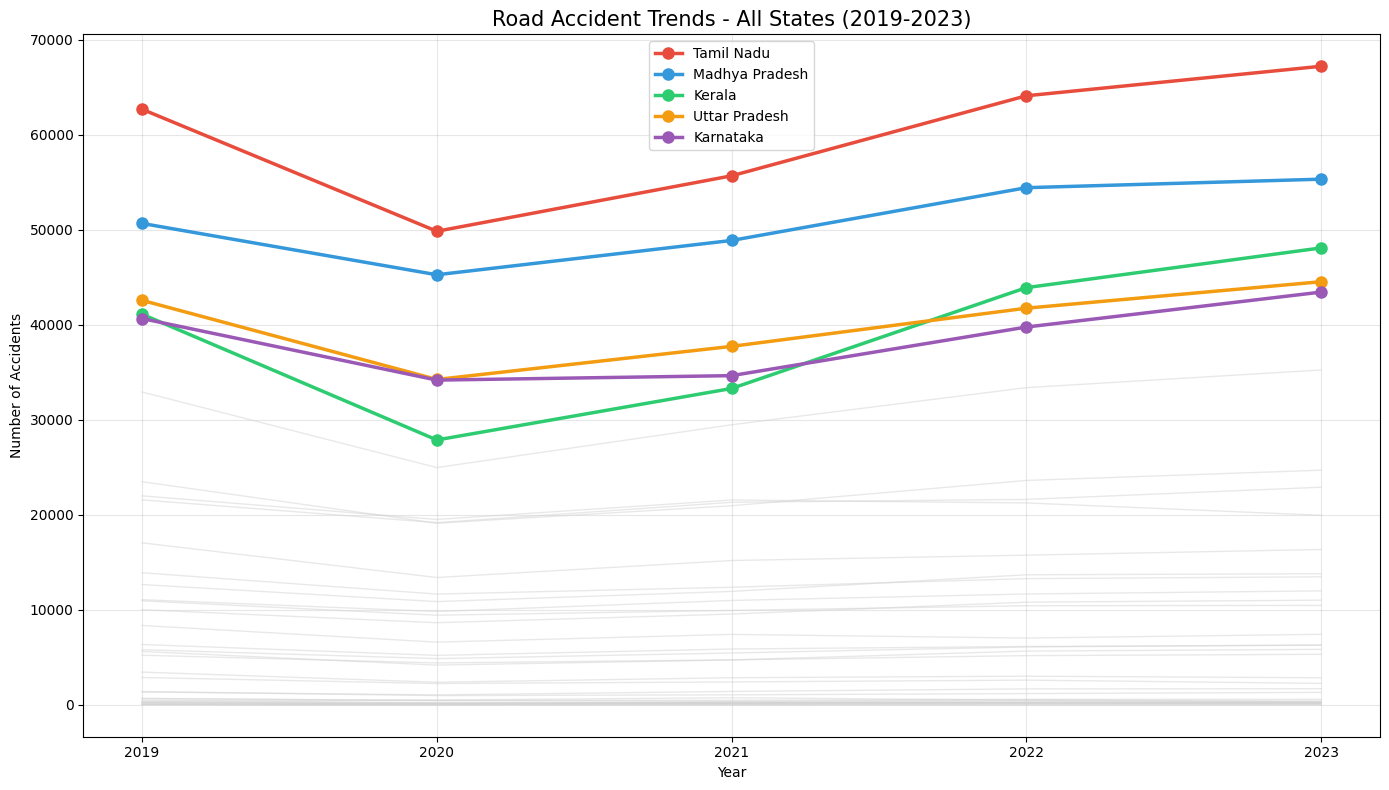

In [12]:
plt.figure(figsize=(14,8))

# All states as light grey lines
for _, row in df_states_clean.iterrows():
    values = row[years].values
    plt.plot(year_labels, values, color='lightgrey', linewidth=1, alpha=0.5)

# Top 5 highlighted on top
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for i, state in enumerate(top5_states):
    values = df_states_clean[df_states_clean['State'] == state][years].values[0]
    plt.plot(year_labels, values, marker='o', linewidth=2.5, 
             markersize=8, label=state, color=colors[i])

plt.title('Road Accident Trends - All States (2019-2023)', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

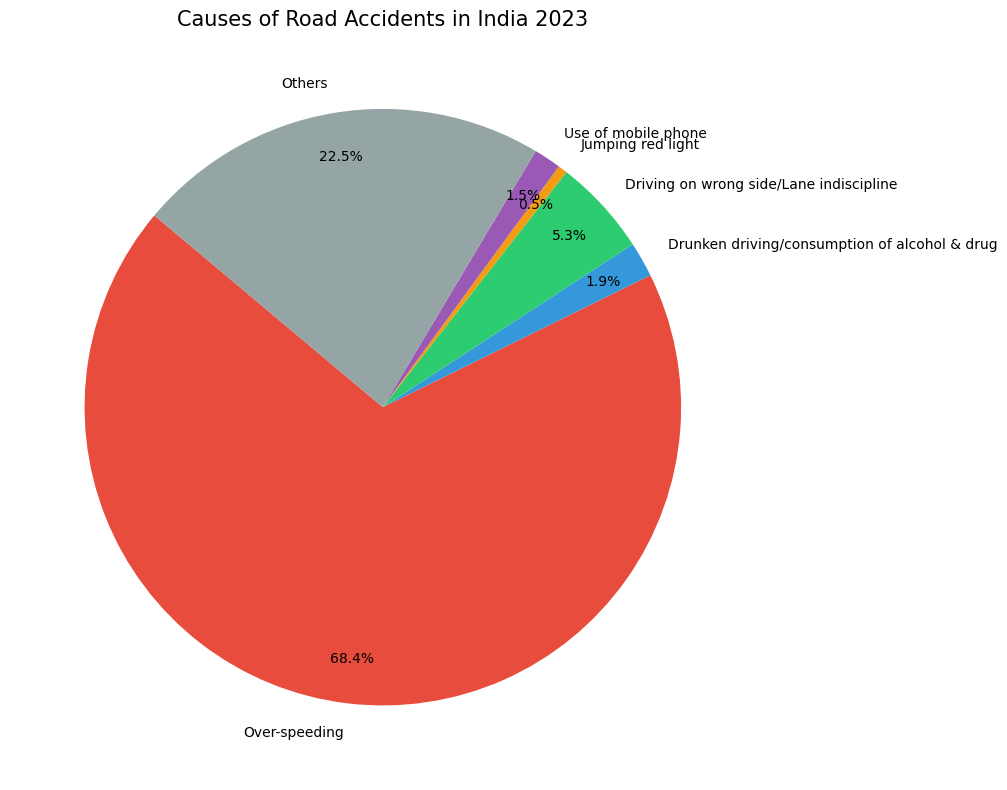

In [13]:
plt.figure(figsize=(10,8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#95a5a6']

plt.pie(df_causes_clean['2023-Accidents'], 
        labels=df_causes_clean['Category'],
        colors=colors,
        autopct='%1.1f%%',
        startangle=140,
        pctdistance=0.85)

plt.title('Causes of Road Accidents in India 2023', fontsize=15)
plt.tight_layout()
plt.show()


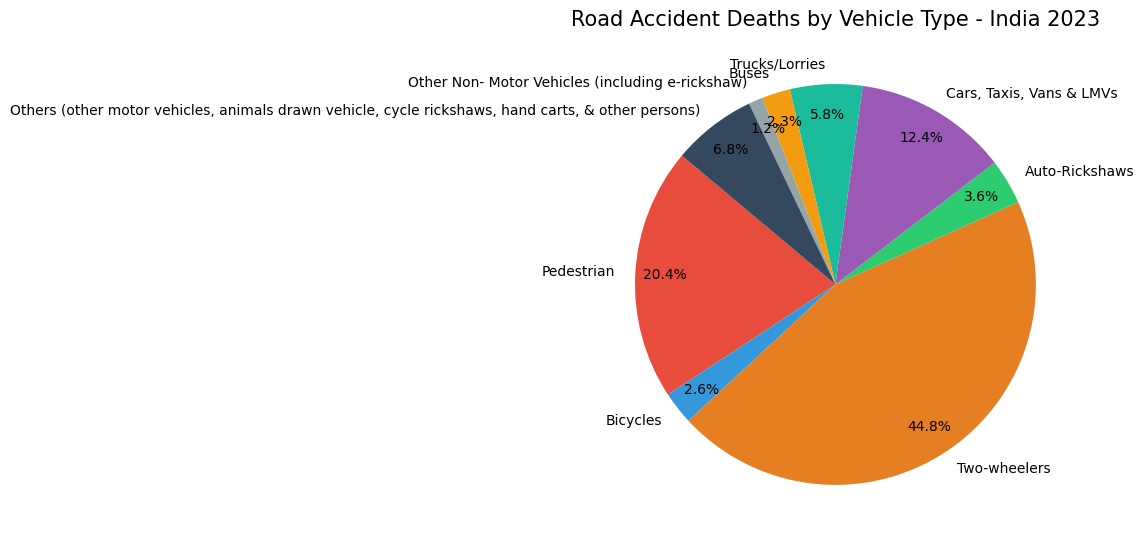

In [14]:
plt.figure(figsize=(10,8))

colors = ['#e74c3c','#3498db','#e67e22','#2ecc71',
          '#9b59b6','#1abc9c','#f39c12','#95a5a6','#34495e']

plt.pie(df_users_clean['Persons killed 2023'],
        labels=df_users_clean['Road-user category'],
        colors=colors,
        autopct='%1.1f%%',
        startangle=140,
        pctdistance=0.85)

plt.title('Road Accident Deaths by Vehicle Type - India 2023', fontsize=15)
plt.tight_layout()
plt.show()

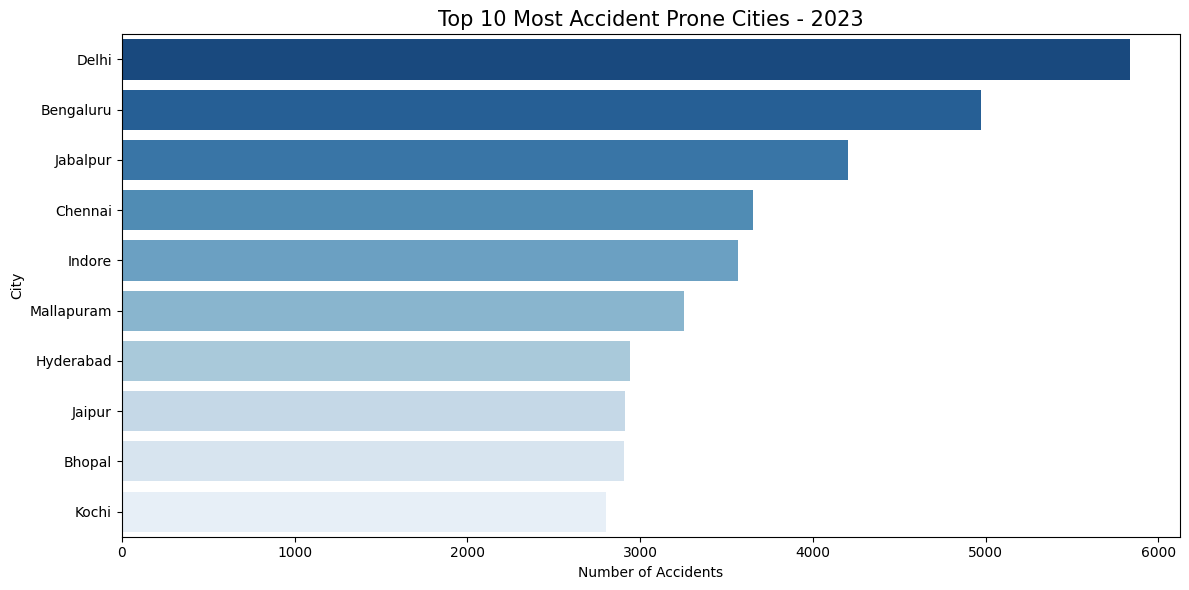

In [16]:
# Remove Total row
df_cities_clean = df_cities[~df_cities['City'].str.contains('Total', na=False)].copy()

# Now plot again
plt.figure(figsize=(12,6))
top10_cities = df_cities_clean.nlargest(10, '2023 Accidents')
sns.barplot(data=top10_cities, x='2023 Accidents', y='City', palette='Blues_r')
plt.title('Top 10 Most Accident Prone Cities - 2023', fontsize=15)
plt.xlabel('Number of Accidents')
plt.ylabel('City')
plt.tight_layout()
plt.show()

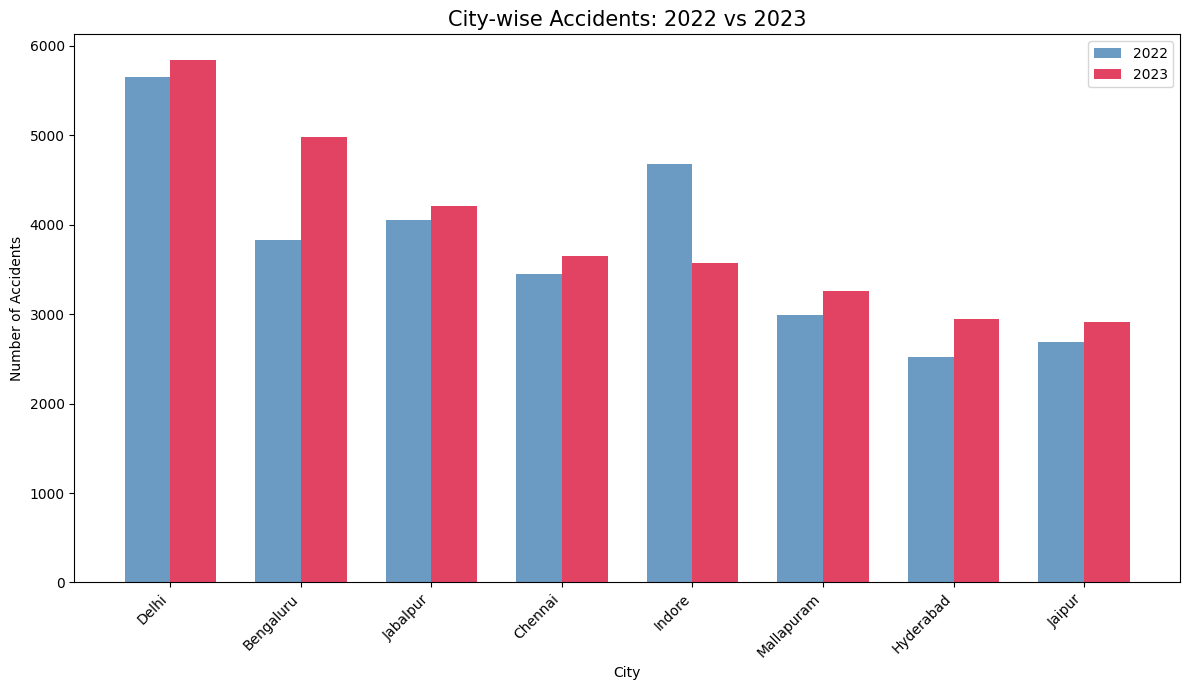

In [17]:
plt.figure(figsize=(12,7))

top8 = df_cities_clean.nlargest(8, '2023 Accidents')
x = range(len(top8))
width = 0.35

plt.bar(x, top8['2022 Accidents'], width=width, 
        label='2022', color='steelblue', alpha=0.8)
plt.bar([i+width for i in x], top8['2023 Accidents'], width=width, 
        label='2023', color='crimson', alpha=0.8)

plt.xticks([i+width/2 for i in x], top8['City'], rotation=45, ha='right')
plt.title('City-wise Accidents: 2022 vs 2023', fontsize=15)
plt.xlabel('City')
plt.ylabel('Number of Accidents')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Load accident dataset
df_accident = pd.read_csv('accident.csv', on_bad_lines='skip')

print("Shape:", df_accident.shape)
print("\nColumns:", df_accident.columns.tolist())
print("\nFirst 3 rows:")
print(df_accident.head(3))
print("\nUnique States:")
print(sorted(df_accident['State'].unique()))

Shape: (300, 13)

Columns: ['Accident_ID', 'State', 'Date', 'Time', 'Reason', 'Number_of_Deaths', 'Number_of_Injuries', 'Road_Type', 'Weather_Conditions', 'Alcohol_Involved', 'Driver_Fatigue', 'Road_Conditions', 'Speed_Limit']

First 3 rows:
  Accident_ID           State        Date      Time                Reason  \
0        1001  Andhra Pradesh  2021-05-01  15:30:00              Speeding   
1        1002       Karnataka  2021-05-02  18:45:00         Drunk Driving   
2        1003           Delhi  2021-05-03  10:15:00  Poor Road Conditions   

   Number_of_Deaths Number_of_Injuries Road_Type Weather_Conditions  \
0                 2                  3     Rural              Sunny   
1                 1                  4     Urban              Rainy   
2                 0                  2     Urban              Foggy   

  Alcohol_Involved Driver_Fatigue Road_Conditions  Speed_Limit  
0               No             No            Poor         60.0  
1              Yes             No 

In [20]:
# Remove corrupted rows where State is a date
df_accident = df_accident[~df_accident['State'].str.contains('-', na=False)]

# Standardize Reason column - fix capitalization inconsistency
df_accident['Reason'] = df_accident['Reason'].str.strip().str.title()

# Extract year from date
df_accident['Year'] = pd.to_datetime(df_accident['Date'], format='mixed').dt.year

print("Shape after cleaning:", df_accident.shape)
print("\nUnique Reasons:")
print(df_accident['Reason'].unique())
print("\nRecords per year:")
print(df_accident['Year'].value_counts().sort_index())
print("\nUnique States:", len(df_accident['State'].unique()))

Shape after cleaning: (299, 14)

Unique Reasons:
<StringArray>
['Speeding', 'Drunk Driving', 'Poor Road Conditions', 'Driver Fatigue']
Length: 4, dtype: str

Records per year:
Year
2021    104
2022    175
2023     20
Name: count, dtype: int64

Unique States: 27


In [21]:
# Aggregate accident data by state
df_accident_agg = df_accident.groupby('State').agg(
    Total_Accidents = ('Accident_ID', 'count'),
    Total_Deaths = ('Number_of_Deaths', 'sum'),
    Total_Injuries = ('Number_of_Injuries', 'sum'),
    Avg_Speed_Limit = ('Speed_Limit', 'mean'),
    Alcohol_Cases = ('Alcohol_Involved', lambda x: (x=='Yes').sum()),
    Fatigue_Cases = ('Driver_Fatigue', lambda x: (x=='Yes').sum()),
    Urban_Cases = ('Road_Type', lambda x: (x=='Urban').sum()),
    Rural_Cases = ('Road_Type', lambda x: (x=='Rural').sum())
).reset_index()

print("Aggregated shape:", df_accident_agg.shape)
print(df_accident_agg.head())

Aggregated shape: (27, 9)
            State  Total_Accidents  Total_Deaths             Total_Injuries  \
0  Andhra Pradesh               25            46  3412133133322304123113452   
1           Assam               18            27         222122322141212222   
2           Bihar                4            10                       6336   
3    Chhattisgarh                9            19                  622131610   
4           Delhi               13            16              2522222533125   

   Avg_Speed_Limit  Alcohol_Cases  Fatigue_Cases  Urban_Cases  Rural_Cases  
0        58.000000             10              7           12           13  
1        48.888889              2              5           11            7  
2        72.500000              1              2            0            4  
3        61.111111              3              5            1            8  
4        48.461538              3              5           11            2  


In [22]:
# Fix Total_Injuries - convert to numeric first
df_accident['Number_of_Injuries'] = pd.to_numeric(df_accident['Number_of_Injuries'], errors='coerce')
df_accident['Number_of_Deaths'] = pd.to_numeric(df_accident['Number_of_Deaths'], errors='coerce')

# Reaggregate
df_accident_agg = df_accident.groupby('State').agg(
    Total_Accidents = ('Accident_ID', 'count'),
    Total_Deaths = ('Number_of_Deaths', 'sum'),
    Total_Injuries = ('Number_of_Injuries', 'sum'),
    Avg_Speed_Limit = ('Speed_Limit', 'mean'),
    Alcohol_Cases = ('Alcohol_Involved', lambda x: (x=='Yes').sum()),
    Fatigue_Cases = ('Driver_Fatigue', lambda x: (x=='Yes').sum()),
    Urban_Cases = ('Road_Type', lambda x: (x=='Urban').sum()),
    Rural_Cases = ('Road_Type', lambda x: (x=='Rural').sum())
).reset_index()

print("Aggregated shape:", df_accident_agg.shape)
print(df_accident_agg.head())

Aggregated shape: (27, 9)
            State  Total_Accidents  Total_Deaths  Total_Injuries  \
0  Andhra Pradesh               25            46              60   
1           Assam               18            27              35   
2           Bihar                4            10              18   
3    Chhattisgarh                9            19              22   
4           Delhi               13            16              36   

   Avg_Speed_Limit  Alcohol_Cases  Fatigue_Cases  Urban_Cases  Rural_Cases  
0        58.000000             10              7           12           13  
1        48.888889              2              5           11            7  
2        72.500000              1              2            0            4  
3        61.111111              3              5            1            8  
4        48.461538              3              5           11            2  


In [23]:
# Merge states dataset with accident aggregated data
df_merged = pd.merge(df_states_clean, df_accident_agg, 
                     on='State', how='left')

print("Merged shape:", df_merged.shape)
print("\nColumns:", df_merged.columns.tolist())
print("\nMissing values:")
print(df_merged.isnull().sum())
print("\nSample:")
print(df_merged.head(3))

Merged shape: (37, 15)

Columns: ['State', '2019 Accidents', '2020 Accidents', '2021 Accidents', '2022 Accidents', '2023 Accidents', '% change from 2022 to 2023', 'Total_Accidents', 'Total_Deaths', 'Total_Injuries', 'Avg_Speed_Limit', 'Alcohol_Cases', 'Fatigue_Cases', 'Urban_Cases', 'Rural_Cases']

Missing values:
State                          0
2019 Accidents                 0
2020 Accidents                 0
2021 Accidents                 0
2022 Accidents                 0
2023 Accidents                 0
% change from 2022 to 2023     0
Total_Accidents               10
Total_Deaths                  10
Total_Injuries                10
Avg_Speed_Limit               10
Alcohol_Cases                 10
Fatigue_Cases                 10
Urban_Cases                   10
Rural_Cases                   10
dtype: int64

Sample:
               State  2019 Accidents  2020 Accidents  2021 Accidents  \
0     Andhra Pradesh         21992.0         19509.0         21556.0   
1  Arunachal Pradesh   

In [24]:
# Fill missing values with 0
cols_to_fill = ['Total_Accidents', 'Total_Deaths', 'Total_Injuries', 
                'Avg_Speed_Limit', 'Alcohol_Cases', 'Fatigue_Cases', 
                'Urban_Cases', 'Rural_Cases']

df_merged[cols_to_fill] = df_merged[cols_to_fill].fillna(0)

# Add Death Rate column
df_merged['Death_Rate'] = round(
    (df_merged['Total_Deaths'] / df_merged['Total_Accidents'].replace(0, 1)) * 100, 2
)

print("✅ Merged dataset ready!")
print("Shape:", df_merged.shape)
print("\nColumns:", df_merged.columns.tolist())

✅ Merged dataset ready!
Shape: (37, 16)

Columns: ['State', '2019 Accidents', '2020 Accidents', '2021 Accidents', '2022 Accidents', '2023 Accidents', '% change from 2022 to 2023', 'Total_Accidents', 'Total_Deaths', 'Total_Injuries', 'Avg_Speed_Limit', 'Alcohol_Cases', 'Fatigue_Cases', 'Urban_Cases', 'Rural_Cases', 'Death_Rate']


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler

# Create Risk Score using combined features
scaler = MinMaxScaler()

df_merged['Cases_Norm'] = scaler.fit_transform(df_merged[['2023 Accidents']])
df_merged['Death_Norm'] = scaler.fit_transform(df_merged[['Death_Rate']])
df_merged['Alcohol_Norm'] = scaler.fit_transform(df_merged[['Alcohol_Cases']])

df_merged['Risk_Score'] = (df_merged['Cases_Norm'] + 
                           df_merged['Death_Norm'] + 
                           df_merged['Alcohol_Norm']) / 3

# Classify risk
def classify_risk(score):
    if score >= 0.35:
        return 'High Risk'
    elif score >= 0.20:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_merged['Risk'] = df_merged['Risk_Score'].apply(classify_risk)

print("Risk Distribution:")
print(df_merged['Risk'].value_counts())

Risk Distribution:
Risk
High Risk      14
Low Risk       14
Medium Risk     9
Name: count, dtype: int64


In [26]:
# Features - now we have MORE columns thanks to merge!
X = df_merged[['2023 Accidents', 'Total_Deaths', 'Total_Injuries',
               'Avg_Speed_Limit', 'Alcohol_Cases', 'Fatigue_Cases',
               'Urban_Cases', 'Rural_Cases', 'Death_Rate']]

y = df_merged['Risk']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Model 1 - Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Model 2 - Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("\nLogistic Regression Accuracy:", round(lr_acc*100, 2), "%")
print("Random Forest Accuracy:", round(rf_acc*100, 2), "%")
print("\nDetailed Report - Random Forest:")
print(classification_report(y_test, rf_pred))

Training samples: 29
Testing samples: 8

Logistic Regression Accuracy: 75.0 %
Random Forest Accuracy: 87.5 %

Detailed Report - Random Forest:
              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00         4
    Low Risk       0.75      1.00      0.86         3
 Medium Risk       0.00      0.00      0.00         1

    accuracy                           0.88         8
   macro avg       0.58      0.67      0.62         8
weighted avg       0.78      0.88      0.82         8



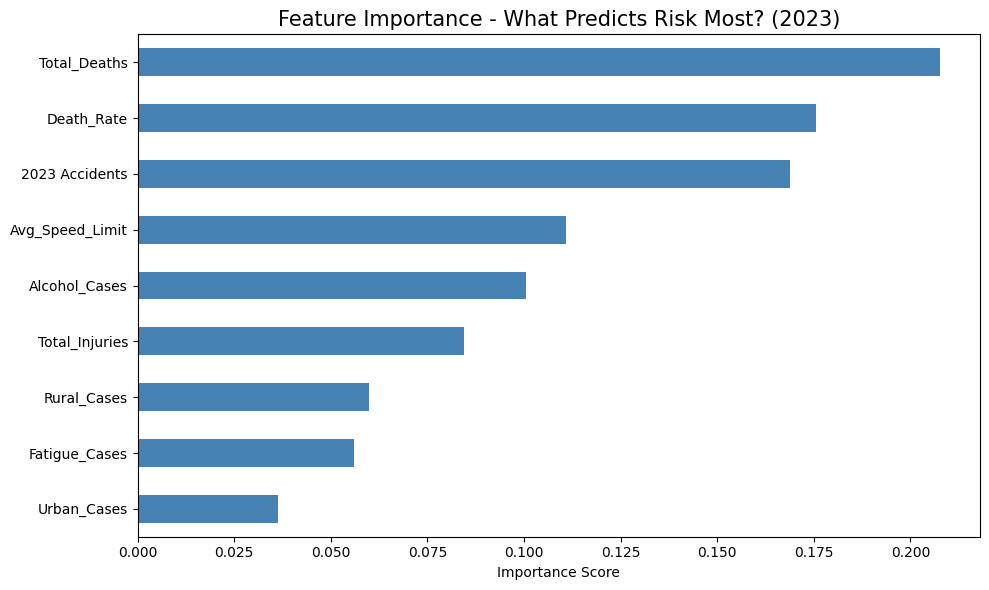

In [27]:
plt.figure(figsize=(10,6))

feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importance.sort_values().plot(kind='barh', color='steelblue')

plt.title('Feature Importance - What Predicts Risk Most? (2023)', fontsize=15)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()